<a href="https://colab.research.google.com/github/babi00/ai4biological-pattern/blob/guido-clean/invasive_plants_analysis/final_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classificatore specie:
- input: immagine
- output label: nativa/non nativa e non invasiva/non nativa e invasiva
La struttura del modello utilizzato è simile a quella precedentemente implementata:
le immagini passano attraverso un modello preallenato (BioCLIP o ResNet) da cui vengono estratti gli embedding
gli embedding allenano un semplice classificatore.

La loss function è stata modificata: ogni classe ha il suo peso (dipendente dalla frequenza della classe).

Durante il training le fasi di estrazione degli embedding e predizione del label sono separate (così che il training sia molto più veloce e leggero). Una volta finito il training viene ricostruito il modello intero, così che il classificatore prenda come input l'immagine (non l'embedding) e restituisca il label (in modo che si possa effettuare successivamente explainability sulle immagini e non solo sugli embedding).

Rispetto al modello di Barbara, estraggo gli embeddings tutti insieme (e non separati per training set e validation set), così da poter effettuare cross validation senza dover ogni volta estrarre gli embeddings.

In [1]:
#@title Imports and downloads
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import functional as TF
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from torchvision import transforms, models
# from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, multilabel_confusion_matrix, confusion_matrix, ConfusionMatrixDisplay, f1_score
# import seaborn as sns
# import requests
# from io import BytesIO
from google.colab import drive
import time
from tqdm import tqdm
!pip install open_clip_torch
import open_clip
# import random
import math
from collections import Counter
import datetime
import json
import os

torch.manual_seed(42)
np.random.seed(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

drive.mount('/content/drive')

# Clone the repository and checkout the 'clean-barbara' branch
!git clone --branch clean-barbara https://github.com/babi00/ai4biological-pattern.git
%cd ai4biological-pattern

# Enable sparse checkout
!git sparse-checkout init --cone

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
Mounted at /content/drive
Cloning into 'ai4biological-pattern'...
remote: Enumerating objects: 735006, done.
remote: Counting objects: 100% (184/184), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 735006 (delta 127), reused 89 (delta 76), pack-reused 734822 (from 3)
Receiving objects: 100% (735006/735006), 8.72 GiB | 47.82 MiB/s, done.
Resolving deltas: 100% (2203/2203), done.
Updating files: 100% (214733/214733), done.
/content/ai4biological-pattern
Updating files: 100% (214731/214731), done.


In [2]:
#@title Training log saving function
def save_training_log(model_name, output_dir, train_losses, val_losses, train_accuracies, val_accuracies, classification_report_dict):
    import datetime
    import json
    import os

    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    log_dir = f"/content/drive/MyDrive/Thesis/{output_dir}/logs"
    os.makedirs(log_dir, exist_ok=True)
    log_path = os.path.join(log_dir, "training_log.json")

    # Load existing logs (if any)
    if os.path.exists(log_path):
        with open(log_path, "r") as f:
            all_logs = json.load(f)
    else:
        all_logs = []

    # Prepare this run's data
    this_log = {
        "model_name": model_name,
        "timestamp": timestamp,
        "final_train_loss": train_losses[-1] if train_losses else None,
        "final_val_loss": val_losses[-1] if val_losses else None,
        "final_train_accuracy": train_accuracies[-1] if train_accuracies else None,
        "final_val_accuracy": val_accuracies[-1] if val_accuracies else None,
        "classification_report_last_epoch": classification_report_dict[-1] if isinstance(classification_report_dict, list) else classification_report_dict,
        "train_loss_history": train_losses,
        "val_loss_history": val_losses,
        "train_accuracy_history": train_accuracies,
        "val_accuracy_history": val_accuracies
    }

    all_logs.append(this_log)

    # Save updated list
    with open(log_path, "w") as f:
        json.dump(all_logs, f, indent=4)

    print(f"📝 Appended log to {log_path}")


In [3]:
#@title Horizontal flip
def hflip(image):
  return TF.hflip(image)

In [4]:
#@title Original Dataset
class InvasiveSpeciesDataset(Dataset):
    def __init__(self, root_dir, transform=None, get_label_fn=None):
        self.root_dir = root_dir
        self.transform = transform
        self.entries = []
        self.label_map = {
            "Invasive" : 0,
            "Non Invasive" : 1
        }

        taxa_folders = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d)) and d != "metadata"]
        for taxon in taxa_folders:
            meta_path = os.path.join(root_dir, "filtered_metadata", f"{taxon}_metadata.csv")
            if not os.path.exists(meta_path):
                continue
            metadata_df = pd.read_csv(meta_path)
            for idx, row in metadata_df.iterrows():
              if pd.isna(row["filename"]):
                  print(f"⚠️ Missing filename in taxon '{taxon}' at index {idx}")
                  continue
              self.entries.append((taxon, row))

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        taxon, row = self.entries[idx]
        filename = str(row["filename"])
        image_path = os.path.join(self.root_dir, taxon, filename)
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = self.label_map.get(row["label"])
        return image, label, idx, taxon

In [5]:
#@title Augmented Dataset
class AugmentedDataset(Dataset):
  def __init__(self, original_dataset, transform=None):
    self.original_dataset = original_dataset
    self.transform = transform
    self.entries = [entry for entry in original_dataset.entries]
    self.root_dir = original_dataset.root_dir
    self.label_map = {
            "Invasive" : 0,
            "Non Invasive" : 1
        }

  def __len__(self):
    return len(self.entries)

  def __getitem__(self, idx):
    taxon, row = self.entries[idx]
    filename = str(row['filename'])
    image_path = os.path.join(self.root_dir, taxon, filename)
    image = Image.open(image_path).convert("RGB")
    if self.transform:
        image = self.transform(image)
    label = self.label_map.get(row["label"])
    return image, label, idx, taxon

In [6]:
#@title Augmented Dataset (Only for lythrum virgatum)
class AugmentedVirgatumDataset(Dataset):
  def __init__(self, original_dataset, transform=None):
    self.original_dataset = original_dataset
    self.transform = transform
    self.entries = [entry for entry in original_dataset.entries if entry[0] == 'lythrum_virgatum']
    self.root_dir = original_dataset.root_dir
    self.label_map = {
            "Invasive" : 0,
            "Non Invasive" : 1
        }

  def __len__(self):
    return len(self.entries)

  def __getitem__(self, idx):
    taxon, row = self.entries[idx]
    filename = str(row['filename'])
    image_path = os.path.join(self.root_dir, taxon, filename)
    image = Image.open(image_path).convert("RGB")
    if self.transform:
        image = self.transform(image)
    label = self.label_map.get(row["label"])
    return image, label, idx, taxon

In [7]:
#@title Return the dataloader of all images and not already separated (also class weights are not present)
def get_data_loader(root_dir, batch_size=32, use_bioclip=True, preprocess=None):
    if use_bioclip and preprocess:
        transform = preprocess
    else:
        transform = transforms.Compose([
          transforms.Resize((224, 224)),
          transforms.ToTensor()
        ])

    dataset = InvasiveSpeciesDataset(
        root_dir=root_dir,
        transform=transform,
    )

    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    return loader

In [8]:
#@title Augmentation functions
def get_augmented_transform_flipping(preprocess=None):

    if preprocess:
        # BioCLIP: use its own preprocessing, plus flipping
        return transforms.Compose([
            transforms.Lambda(lambda img: TF.hflip(img)),
            preprocess
        ])
    else:
        # ResNet or default: manual transform
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Lambda(lambda img: TF.hflip(img)),
            transforms.ToTensor()
        ])


def get_augmented_transform_jitter(preprocess=None):

    if preprocess:
        # BioCLIP: use its own preprocessing, plus jittering (no hue modification)
        return transforms.Compose([
            transforms.ColorJitter(0.3, 0.3, 0.3),
            preprocess
        ])
    else:
        # ResNet or default: manual transform
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ColorJitter(0.3, 0.3, 0.3),
            transforms.ToTensor()
        ])

In [9]:
#@title Augmented DataLoader (N.B. remember parameter virgatum=T/F to augment the whole dataset or just Lythrum Virgatum)
def get_data_loader_augmented(root_dir, batch_size=32, use_bioclip=True, preprocess=None, augmentation='flipping', virgatum=False):
    if use_bioclip and preprocess:
        original_transform = preprocess
    else:
        original_transform = transforms.Compose([
          transforms.Resize((224, 224)),
          transforms.ToTensor(),
          # transforms.RandomHorizontalFlip(p=1.0)
        ])

    if augmentation=='flipping':
      augmented_transform = get_augmented_transform_flipping(preprocess if use_bioclip else None)
    elif augmentation=='jittering':
      augmented_transform = get_augmented_transform_jitter(preprocess if use_bioclip else None)
    else:
      print("Error in the augmentation!")
      augmented_transform = -1 #this will break after


    original_dataset = InvasiveSpeciesDataset(
        root_dir=root_dir,
        transform=original_transform,
    )

    if virgatum:
      augmented_dataset = AugmentedVirgatumDataset(
          original_dataset=original_dataset,
          transform=augmented_transform,
      )
    else:
      augmented_dataset = AugmentedDataset(
          original_dataset=original_dataset,
          transform=augmented_transform,
      )

    augmented_loader = DataLoader(augmented_dataset, batch_size=32, shuffle=False)

    return augmented_loader

In [10]:
#@title 2.Define the embedding extractor:
#ResNet without the last FC layer
def get_resnet_embeddings_extractor_model():
    #Use a pre-trained ResNet18 model
    model = models.resnet18(weights='IMAGENET1K_V1')

    #Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    embeddings_extractor= nn.Sequential(*list(model.children())[:-1]) #removes the last FC layer
    print("Model obtained...")

    return embeddings_extractor

#BioCLIP model
def get_bioclip_embeddings_extractor_model(device, bioclip_version=2):
    if bioclip_version==2:
        print("BioCLIP 2!")
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip-2')
    else:
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip')
    print("Model obtained...")
    model.to(device)
    model.eval()
    return model, preprocess

In [11]:
#@title 3. Extract embeddings using the embeddings_extractor and return the embeddings tensors
def extract_embeddings(dataloader, embeddings_extractor, device, embeddings_save_path, augmented=False, use_bioclip=True, dataset=None):
    embeddings_extractor.eval()
    all_embeddings = []
    all_labels = []
    all_ids = []
    all_groups = []  # ✅ NEW: store taxa names

    with torch.no_grad():
      for images, labels, obs_id, taxon in tqdm(dataloader, desc='Extracting embeddings'):
          images = images.to(device)
          if use_bioclip:
              embeddings = embeddings_extractor.encode_image(images)
              embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)  # Optional: normalize
          else:
              embeddings = embeddings_extractor(images).view(images.size(0), -1)

          all_embeddings.append(embeddings.cpu())
          all_labels.append(labels)
          all_ids.extend(obs_id)

          all_groups.extend(taxon) #remember to use extend and not append to get a flat list and not a list of tuples of the batch

          # # ✅ OLD: reconstruct taxa names directly here
          # if dataset is not None:
          #     for i in obs_id:
          #         taxon, _ = dataset.entries[int(i)]
          #         all_groups.append(taxon)

    embeddings_tensors = torch.cat(all_embeddings, dim=0).to(device)
    labels_tensors = torch.cat(all_labels, dim=0).to(device)
    obs_id_tensor = torch.tensor(all_ids).to(device)

    all_embeddings = {
       'embeddings' : embeddings_tensors,
       'labels' : labels_tensors,
       'ids' : obs_id_tensor,
       'groups': all_groups  # ✅ Save group names
    }

    if augmented==False:
      torch.save(all_embeddings, embeddings_save_path)

    # embedding_size = embeddings_tensors.shape[1] #useful for classifier

    return all_embeddings

In [12]:
#@title Split the embeddings 80-20, then add the augmentation to the training set

### OLD FUNCTION WHERE REMOVE_SPECIES WHERE REMOVED FROM BOTH TRAINING SET AND VALIDATION SET
def split_embeddings_1(embeddings_dict, augmented_embeddings_dict=None, val_percentage=0.2, remove_species=None):

    """Split the embeddings and not the images into training set and validation set"""

    embeddings_tensors = embeddings_dict["embeddings"]
    labels_tensors = embeddings_dict["labels"]
    obs_id_tensor = embeddings_dict["ids"]


    #modified to remove species
    embeddings_np = embeddings_tensors.cpu().numpy()
    labels_np = labels_tensors.cpu().numpy()
    obs_id_np = obs_id_tensor.cpu().numpy()
    groups_np = np.array(embeddings_dict["groups"])  # ✅ Directly use stored groups

    if remove_species != None:
      #mask
      indices = [groups_np[i] not in remove_species for i in range(len(groups_np))]

      embeddings_np_reduced = np.array([embeddings_np[i] for i in range(len(indices)) if indices[i]])
      labels_np_reduced = np.array([labels_np[i] for i in range(len(indices)) if indices[i]])
      obs_id_np_reduced = np.array([obs_id_np[i] for i in range(len(indices)) if indices[i]])
      groups_np_reduced = [groups_np[i] for i in range(len(indices)) if indices[i]]

    else:
      embeddings_np_reduced = embeddings_np
      labels_np_reduced = labels_np
      obs_id_np_reduced = obs_id_np
      groups_np_reduced = groups_np

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # or get from caller
    embeddings_tensors = torch.from_numpy(np.stack(embeddings_np_reduced)).to(device)
    labels_tensors = torch.from_numpy(np.array(labels_np_reduced)).to(device)
    obs_id_tensor = torch.from_numpy(np.array(obs_id_np_reduced)).to(device)
    #end of modification

    embedding_size = embeddings_tensors.shape[1] #useful for classifier
    dataset = torch.utils.data.TensorDataset(embeddings_tensors, labels_tensors, obs_id_tensor)

    train_size = int((1-val_percentage) * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    #if using augmentation
    if augmented_embeddings_dict:
      print("Augmenting train dataset...")
      aug_embeddings_tensors = augmented_embeddings_dict["embeddings"]
      aug_labels_tensors = augmented_embeddings_dict["labels"]
      aug_obs_id_tensor = augmented_embeddings_dict["ids"]

      #modification to remove species
      aug_embeddings_np = aug_embeddings_tensors.cpu().numpy()
      aug_labels_np = aug_labels_tensors.cpu().numpy()
      aug_obs_id_np = aug_obs_id_tensor.cpu().numpy()
      aug_groups_np = np.array(augmented_embeddings_dict["groups"])  # ✅ Directly use stored groups

      if remove_species != None:
        indices = [aug_groups_np[i] not in remove_species for i in range(len(aug_groups_np))]

        #this is to remove species (e.g hyssopifolia) from augmentation
        aug_embeddings_np_reduced = np.array([aug_embeddings_np[i] for i in range(len(indices)) if indices[i]])
        aug_labels_np_reduced = np.array([aug_labels_np[i] for i in range(len(indices)) if indices[i]])
        aug_obs_id_np_reduced = np.array([aug_obs_id_np[i] for i in range(len(indices)) if indices[i]])
        aug_groups_np_reduced = np.array([aug_groups_np[i] for i in range(len(indices)) if indices[i]])


      else:
        aug_embeddings_np_reduced = aug_embeddings_np
        aug_labels_np_reduced = aug_labels_np
        aug_obs_id_np_reduced = aug_obs_id_np
        aug_groups_np_reduced = aug_groups_np

      device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # or get from caller
      aug_embeddings_tensors = torch.from_numpy(np.stack(aug_embeddings_np_reduced)).to(device)
      aug_labels_tensors = torch.from_numpy(np.array(aug_labels_np_reduced)).to(device)
      aug_obs_id_tensor = torch.from_numpy(np.array(aug_obs_id_np_reduced)).to(device)

      #end of modification
      augmented_train_dataset = torch.utils.data.TensorDataset(aug_embeddings_tensors, aug_labels_tensors, aug_obs_id_tensor)

      #concatenate train dataset with augmented train dataset
      train_dataset = ConcatDataset([train_dataset, augmented_train_dataset])

    label_counts = Counter()
    for _, label, _ in train_dataset:
        label_counts[int(label)] += 1

    print("🔢 Class distribution in train set:", label_counts)

    # total = sum(label_counts.values())
    class_weights = torch.tensor([
        1.0 / math.log(1.02 + label_counts[0]),
        1.0 / math.log(1.02 + label_counts[1])
    ], dtype=torch.float)

    print("⚖️ Class weights:", class_weights)

    g = torch.Generator()
    g.manual_seed(42)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

    return train_loader, val_loader, class_weights, embedding_size

### NEW VERSION WHERE I RETAIN THE SPECIES IN REMOVE_SPECIES IN THE VALIDATION SPLIT
def split_embeddings_2(embeddings_dict, augmented_embeddings_dict=None, val_percentage=0.2, remove_species=None):
    """Split the embeddings into training and validation sets, then remove specific species only from training."""

    embeddings_tensors = embeddings_dict["embeddings"]
    labels_tensors = embeddings_dict["labels"]
    obs_id_tensor = embeddings_dict["ids"]
    groups_np = np.array(embeddings_dict["groups"])  # Taxa names

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    dataset = torch.utils.data.TensorDataset(embeddings_tensors, labels_tensors, obs_id_tensor)
    full_indices = np.arange(len(dataset))

    # Shuffle and split
    g = torch.Generator()
    g.manual_seed(42)
    train_size = int((1 - val_percentage) * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=g)

    # Filter remove_species only from training set
    if remove_species is not None:
        train_indices = train_dataset.indices if hasattr(train_dataset, 'indices') else train_dataset
        filtered_train_data = [
            dataset[i] for i in train_indices
            if groups_np[i] not in remove_species
        ]
        train_dataset = torch.utils.data.TensorDataset(
            torch.stack([item[0] for item in filtered_train_data]),
            torch.stack([item[1] for item in filtered_train_data]),
            torch.stack([item[2] for item in filtered_train_data])
        )

    # Augmented embeddings (optional)
    if augmented_embeddings_dict:
        print("Augmenting train dataset...")
        aug_embeddings = augmented_embeddings_dict["embeddings"]
        aug_labels = augmented_embeddings_dict["labels"]
        aug_ids = augmented_embeddings_dict["ids"]
        aug_groups = np.array(augmented_embeddings_dict["groups"])

        if remove_species is not None:
            keep_mask = np.array([g not in remove_species for g in aug_groups])
            aug_embeddings = aug_embeddings[keep_mask]
            aug_labels = aug_labels[keep_mask]
            aug_ids = aug_ids[keep_mask]

        aug_dataset = torch.utils.data.TensorDataset(aug_embeddings, aug_labels, aug_ids)
        train_dataset = ConcatDataset([train_dataset, aug_dataset])

    # Compute class weights
    label_counts = Counter()
    for _, label, _ in train_dataset:
        label_counts[int(label)] += 1

    print("🔢 Class distribution in train set:", label_counts)

    class_weights = torch.tensor([
        1.0 / math.log(1.02 + label_counts[0]),
        1.0 / math.log(1.02 + label_counts[1])
    ], dtype=torch.float)

    print("⚖️ Class weights:", class_weights)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

    embedding_size = embeddings_tensors.shape[1]
    return train_loader, val_loader, class_weights, embedding_size

In [13]:
#@title Classifier
class InvasiveSpeciesClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_dim=256, num_classes=2):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(), #consider adding a Dropout layer
            # nn.Dropout(0.3), #We remove the dropout layer
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

In [14]:
#@title Early Stopping class

#Patience: how many epochs to wait after last improvements
#delta: minimum change in validation to be considered improvement
class EarlyStopping:

    def __init__(self, patience=5, delta=0.01, verbose=False):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                if self.verbose:
                    print("Stopping early as no improvement has been observed.")

In [21]:
#@title 4. Training function
def train_classifier(train_loader, val_loader, feature_extractor, classifier, optimizer, criterion, device, output_dir, model_name, num_epoch=10, verbose=True, save_classifier=False, do_early_stopping=False):

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    early_stopping = EarlyStopping(patience=50, delta=0, verbose=True)

    for epoch in range(num_epoch):
        print(f"\n🔁 Epoch {epoch + 1}/{num_epoch}")
        classifier.train()
        running_loss, correct, total = 0, 0, 0

        for embeddings, labels, _ in tqdm(train_loader, desc="Training"): # Unpack all three values
            outputs = classifier(embeddings)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * embeddings.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        val_loss, val_acc, y_true, y_pred = evaluate_classifier(
            val_loader, feature_extractor, classifier, criterion, device
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        if verbose:
            print(f"📉 Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
            print(f"📈 Val Loss:   {val_loss:.4f} | Accuracy: {val_acc:.4f}")

            print("\n📋 Classification Report:")
            report_dict = classification_report(y_true, y_pred, labels=[0, 1], target_names=["Invasive", "Non Invasive"], zero_division=0, output_dict=True)
            print(classification_report(y_true, y_pred, labels=[0, 1], target_names=["Invasive", "Non Invasive"], zero_division=0, output_dict=False))

            #plot confusion matrix
            cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
            fig, ax = plt.subplots(figsize=(6, 6))
            im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
            ax.figure.colorbar(im, ax=ax)
            classes = ["Invasive", "Non Invasive"]

            # Show all ticks and label them
            ax.set(xticks=np.arange(len(classes)),
                yticks=np.arange(len(classes)),
                xticklabels=classes,
                yticklabels=classes,
                ylabel='True label',
                xlabel='Predicted label',
                title='Validation Confusion Matrix')

            # Rotate the tick labels and set alignment.
            plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

            # Loop over data dimensions and create text annotations.
            fmt = 'd'
            thresh = cm.max() / 2. if cm.max() > 0 else 1
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(j, i, format(cm[i, j], fmt),
                            ha="center", va="center",
                            color="white" if cm[i, j] > thresh else "black")

            fig.tight_layout()
            plt.grid(False)
            plt.show()
        else:
          report_dict = None

        if do_early_stopping:
          # Check early stopping condition
          early_stopping.check_early_stop(val_loss)

          if early_stopping.stop_training:
            print(f"Early stopping at epoch {epoch}")
            break


    torch.save(classifier.state_dict(), f'classifier_head_{model_name}.pth')
    google_drive_path = f'/content/drive/MyDrive/Thesis/{output_dir}/classifier_head_{model_name}.pth'
    torch.save(classifier.state_dict(), google_drive_path)

    return train_losses, train_accuracies, val_losses, val_accuracies, report_dict

In [16]:
#@title 5. Evaluation function
def evaluate_classifier(loader, feature_extractor, classifier, criterion, device):
    classifier.eval()
    total_loss, correct, total = 0, 0, 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for embeddings, labels, obs_ids in tqdm(loader, desc="Evaluating"): # Unpack all three values
            embeddings, labels = embeddings.to(device), labels.to(device)
            outputs = classifier(embeddings)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * embeddings.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc, all_labels, all_preds

In [17]:
#@title Focal loss function

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        alpha: Class weighting (tensor or list), same as in CrossEntropyLoss
        gamma: Focusing parameter (higher → more focus on hard samples) (gamma=0 => cross entropy loss)
        reduction: 'mean', 'sum', or 'none'
        """
        super(FocalLoss, self).__init__()
        self.alpha=alpha
        self.gamma=gamma
        self.reduction=reduction

    def forward(self, inputs, targets):
        #cross entropy per sample (no reduction)
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')

        #convert to probabilities of true class for modulating factor
        pt = torch.exp(-ce_loss) #ce = -log(pt), so pt = e^(-ce), model confidence of true class

        #focal loss formula (focal term)
        focal_loss = ((1-pt)**self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean() #return average loss per batch
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


In [18]:
#@title Full Model
class FullModel(nn.Module):
    def __init__(self, embedding_model, classifier_head):
        super().__init__()
        self.embedding_model = embedding_model
        self.classifier_head = classifier_head

    def forward(self, x):
        with torch.no_grad():
            if hasattr(self.encoder, 'encode_image'):
                features = self.encoder.encode_image(x)
            else:
                features = self.encoder(x)

        if features.ndim == 4:
            features = features.view(features.size(0), -1)

        return self.classifier_head(features)

In [19]:
#@title Create model and predict
def create_model_and_predict(folder_name="taxas", use_bioclip=True, bioclip_version=None, augmentation=False, augmentation_factor=2,
                             virgatum=False, loss_type='CE', output_dir="invasive_species",
                             model_name="prova", verbose=True, save_model=True, embeddings_save_path=None,
                             epochs=50, debug_subset_size=None, do_early_stopping=False, remove_species=None, keep_hys_in_val = False):

    start_time = time.time()

    model_name = f'bioclip_2_{model_name}' if use_bioclip and bioclip_version==2 else f'bioclip_1_{model_name}' if use_bioclip else f'resnet_{model_name}'

    github = '/content/ai4biological-pattern/barbara_new'
    github_repository = f'{github}/{folder_name}'

    if not os.path.isdir(github_repository): #check if data has already been downloaded
        !git sparse-checkout set barbara_new/{folder_name}
        !git checkout clean-barbara

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    if use_bioclip:
        feature_extractor, preprocess = get_bioclip_embeddings_extractor_model(device, bioclip_version)
        feature_extractor = feature_extractor.to(device)
    else:
        feature_extractor = get_resnet_embeddings_extractor_model()
        feature_extractor = feature_extractor.to(device)
        preprocess = None
    print("Feature extractor obtained..")

    dataset = InvasiveSpeciesDataset(root_dir=github_repository, transform=preprocess if use_bioclip else None)

    if os.path.exists(embeddings_save_path):

        print("✅ Embeddings already exist, loading from file...")
        embeddings_dict = torch.load(embeddings_save_path)

        img_loader = get_data_loader(root_dir=github_repository)

        if augmentation:
          #only extract embeddings for augmentated data
          augmented_loader = get_data_loader_augmented(root_dir=github_repository, augmentation='flipping')
          augmented_embeddings_dict = extract_embeddings(augmented_loader, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip)

          if virgatum:
            augmented_virgatum_loader = get_data_loader_augmented(root_dir=github_repository, augmentation='flipping', virgatum=True)
            augmented_virgatum_embeddings_dict = extract_embeddings(augmented_virgatum_loader, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip)

            augmented_embeddings_dict = {
              "embeddings": torch.cat([augmented_embeddings_dict["embeddings"], augmented_virgatum_embeddings_dict["embeddings"]]),
              "labels": torch.cat([augmented_embeddings_dict["labels"], augmented_virgatum_embeddings_dict["labels"]]),
              "ids": torch.cat([augmented_embeddings_dict["ids"], augmented_virgatum_embeddings_dict["ids"]]),
              "groups": augmented_embeddings_dict["groups"] + augmented_virgatum_embeddings_dict["groups"]
            }

          if augmentation_factor==3:
            augmented_loader_2 = get_data_loader_augmented(root_dir=github_repository, augmentation='jittering')
            augmented_embeddings_dict_2 = extract_embeddings(augmented_loader_2, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip)

            augmented_embeddings_dict = {
              "embeddings": torch.cat([augmented_embeddings_dict["embeddings"], augmented_embeddings_dict_2["embeddings"]]),
              "labels": torch.cat([augmented_embeddings_dict["labels"], augmented_embeddings_dict_2["labels"]]),
              "ids": torch.cat([augmented_embeddings_dict["ids"], augmented_embeddings_dict_2["ids"]]),
              "groups": augmented_embeddings_dict["groups"] + augmented_embeddings_dict_2["groups"]
            }

            if virgatum:
              augmented_virgatum_loader_2 = get_data_loader_augmented(root_dir=github_repository, augmentation='flipping', virgatum=True)
              augmented_virgatum_embeddings_dict_2 = extract_embeddings(augmented_virgatum_loader_2, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip)

              augmented_embeddings_dict = {
                "embeddings": torch.cat([augmented_embeddings_dict["embeddings"], augmented_virgatum_embeddings_dict_2["embeddings"]]),
                "labels": torch.cat([augmented_embeddings_dict["labels"], augmented_virgatum_embeddings_dict_2["labels"]]),
                "ids": torch.cat([augmented_embeddings_dict["ids"], augmented_virgatum_embeddings_dict_2["ids"]]),
                "groups": augmented_embeddings_dict["groups"] + augmented_virgatum_embeddings_dict_2["groups"]
              }

        else:
          augmented_embeddings_dict=None

        if debug_subset_size is not None:
          print(f"⚠ Debug mode: using only the first {debug_subset_size} embeddings.")
          embeddings_dict['embeddings'] = embeddings_dict['embeddings'][:debug_subset_size]
          embeddings_dict['labels'] = embeddings_dict['labels'][:debug_subset_size]
          embeddings_dict['ids'] = embeddings_dict['ids'][:debug_subset_size]

          if augmentation:
            augmented_embeddings_dict['embeddings'] = augmented_embeddings_dict['embeddings'][:debug_subset_size]
            augmented_embeddings_dict['labels'] = augmented_embeddings_dict['labels'][:debug_subset_size]
            augmented_embeddings_dict['ids'] = augmented_embeddings_dict['ids'][:debug_subset_size]
          else:
            augmented_embeddings_dict=None


        #to this function I will pass both extracted embeddings and augmented embeddings (if they exist)
        if keep_hys_in_val:
          embeddings_train_loader, embeddings_val_loader, class_weights, input_size = split_embeddings_2(embeddings_dict, augmented_embeddings_dict, val_percentage=0.2, remove_species=remove_species)
        else:
          embeddings_train_loader, embeddings_val_loader, class_weights, input_size = split_embeddings_1(embeddings_dict, augmented_embeddings_dict, val_percentage=0.2, remove_species=remove_species)

    else:

        img_loader = get_data_loader(root_dir=github_repository)
        print("Dataloader obtained..")

        #this function also saves embeddings in the desired path
        #input size is the same for training and validation, is is the size (number of features) of the single embedding.
        embeddings_dict = extract_embeddings(dataloader=img_loader, embeddings_extractor=feature_extractor, device=device, embeddings_save_path=embeddings_save_path, use_bioclip=use_bioclip, dataset=dataset)

        if augmentation:
          #only extract embeddings for augmentated data
          augmented_loader = get_data_loader_augmented(root_dir=github_repository)
          augmented_embeddings_dict = extract_embeddings(augmented_loader, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip)

          if virgatum:
            augmented_virgatum_loader = get_data_loader_augmented(root_dir=github_repository, augmentation='flipping', virgatum=True)
            augmented_virgatum_embeddings_dict = extract_embeddings(augmented_virgatum_loader, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip)

            augmented_embeddings_dict = {
              "embeddings": torch.cat([augmented_embeddings_dict["embeddings"], augmented_virgatum_embeddings_dict["embeddings"]]),
              "labels": torch.cat([augmented_embeddings_dict["labels"], augmented_virgatum_embeddings_dict["labels"]]),
              "ids": torch.cat([augmented_embeddings_dict["ids"], augmented_virgatum_embeddings_dict["ids"]])
            }

          if augmentation_factor==3:
            augmented_loader_2 = get_data_loader_augmented(root_dir=github_repository, augmentation='jittering')
            augmented_embeddings_dict_2 = extract_embeddings(augmented_loader_2, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip)

            augmented_embeddings_dict = {
              "embeddings": torch.cat([augmented_embeddings_dict["embeddings"], augmented_embeddings_dict_2["embeddings"]]),
              "labels": torch.cat([augmented_embeddings_dict["labels"], augmented_embeddings_dict_2["labels"]]),
              "ids": torch.cat([augmented_embeddings_dict["ids"], augmented_embeddings_dict_2["ids"]])
            }

            if virgatum:
              augmented_virgatum_loader_2 = get_data_loader_augmented(root_dir=github_repository, augmentation='flipping', virgatum=True)
              augmented_virgatum_embeddings_dict_2 = extract_embeddings(augmented_virgatum_loader_2, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip)

              augmented_embeddings_dict = {
                "embeddings": torch.cat([augmented_embeddings_dict["embeddings"], augmented_virgatum_embeddings_dict_2["embeddings"]]),
                "labels": torch.cat([augmented_embeddings_dict["labels"], augmented_virgatum_embeddings_dict_2["labels"]]),
                "ids": torch.cat([augmented_embeddings_dict["ids"], augmented_virgatum_embeddings_dict_2["ids"]])
              }

        else:
          augmented_embeddings_dict=None

        if debug_subset_size is not None:
          print(f"⚠ Debug mode: using only the first {debug_subset_size} embeddings.")
          embeddings_dict['embeddings'] = embeddings_dict['embeddings'][:debug_subset_size]
          embeddings_dict['labels'] = embeddings_dict['labels'][:debug_subset_size]
          embeddings_dict['ids'] = embeddings_dict['ids'][:debug_subset_size]

          if augmentation:
            augmented_embeddings_dict['embeddings'] = augmented_embeddings_dict['embeddings'][:debug_subset_size]
            augmented_embeddings_dict['labels'] = augmented_embeddings_dict['labels'][:debug_subset_size]
            augmented_embeddings_dict['ids'] = augmented_embeddings_dict['ids'][:debug_subset_size]
          else:
            augmented_embeddings_dict=None

        embeddings_train_loader, embeddings_val_loader, class_weights, input_size = split_embeddings(embeddings_dict, augmented_embeddings_dict, val_percentage=0.2, remove_species=remove_species)


    classifier = InvasiveSpeciesClassifier(embedding_dim=input_size).to(device)
    if loss_type=='CE':
      criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    elif loss_type=='FL':
       criterion = FocalLoss(alpha=class_weights.to(device), gamma=2, reduction='mean')
    optimizer = optim.Adam(classifier.parameters(), lr=1e-4)


    train_losses, train_accuracies, val_losses, val_accuracies, report_dict = train_classifier(
        train_loader=embeddings_train_loader,
        val_loader=embeddings_val_loader,
        feature_extractor=feature_extractor,
        classifier=classifier,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        output_dir=output_dir,
        model_name=model_name,
        num_epoch=epochs,
        verbose=verbose,
        save_classifier=save_model,
        do_early_stopping=do_early_stopping
    )

    # Save results
    save_training_log(model_name, output_dir, train_losses, val_losses, train_accuracies, val_accuracies, report_dict)

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'bo-', label='Train Loss')
    plt.plot(epochs, val_losses, 'ro-', label='Val Loss')
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'bo-', label='Train Accuracy')
    plt.plot(epochs, val_accuracies, 'ro-', label='Val Accuracy')
    plt.title("Accuracy over Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    full_model = FullModel(feature_extractor, classifier)
    print("Full model built...")
    full_model.eval()

    if save_model:
      torch.save(full_model.state_dict(), f'full_{model_name}.pth')
      google_drive_path = f'/content/drive/MyDrive/Thesis/{output_dir}/full_{model_name}.pth'
      torch.save(full_model.state_dict(), google_drive_path)

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Total execution time: {elapsed_time:.2f} seconds")

    #return the validation loss and accuracy for the last epoch
    return val_losses[-1], val_accuracies[-1]

## Testing just removing Hyssopifolia from training but keeping it in validation
#### This has been done by choosing the appropriate "split_embeddings" function

Updating files: 100% (45444/45444), done.
Already on 'clean-barbara'
Your branch is up to date with 'origin/clean-barbara'.
Using device: cuda
BioCLIP 2!


open_clip_config.json:   0%|          | 0.00/534 [00:00<?, ?B/s]

open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Model obtained...
Feature extractor obtained..
✅ Embeddings already exist, loading from file...
🔢 Class distribution in train set: Counter({1: 16399, 0: 12238})
⚖️ Class weights: tensor([0.1062, 0.1030])

🔁 Epoch 1/50


Evaluating: 100%|██████████| 284/284 [00:00<00:00, 1064.26it/s]


...


🔁 Epoch 20/50


Evaluating: 100%|██████████| 284/284 [00:00<00:00, 1058.11it/s]



🔁 Epoch 21/50


Evaluating: 100%|██████████| 284/284 [00:00<00:00, 1054.67it/s]


Stopping early as no improvement has been observed.
Early stopping at epoch 20
📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


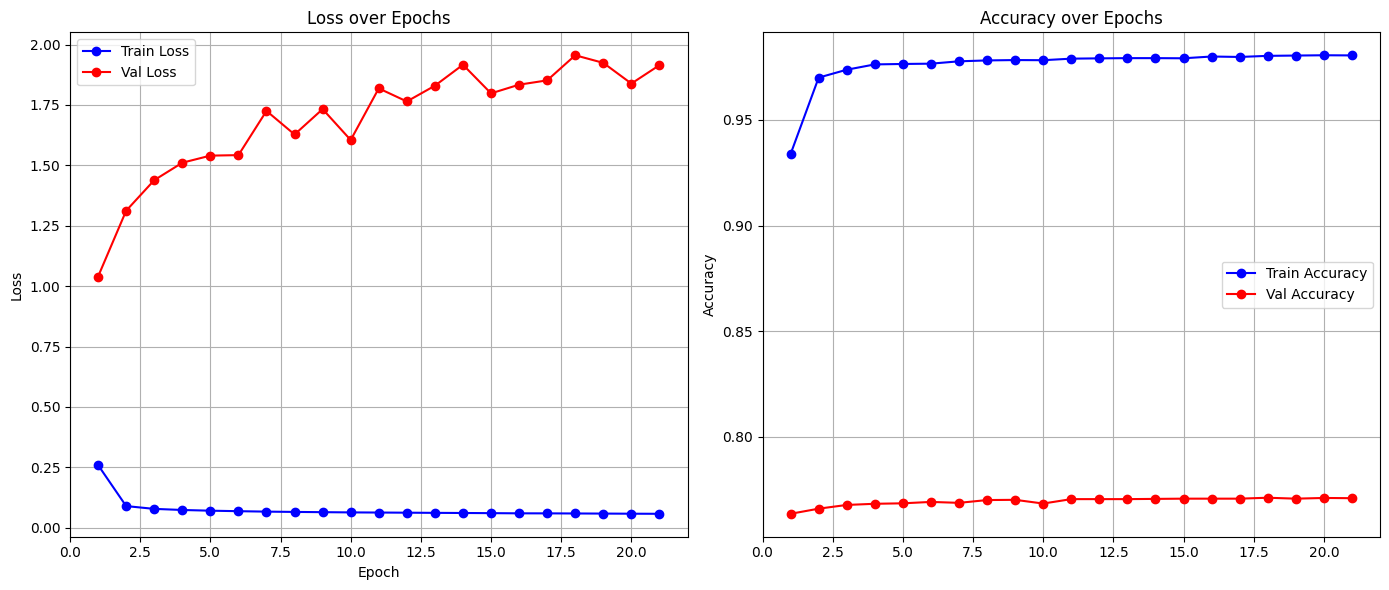

Full model built...
Total execution time: 97.75 seconds


(1.9144432350909395, 0.7709688085528491)

In [ ]:
#@title No hyssopifolia (no augmentation)

remove_species=['lythrum_hyssopifolia']

model_name_BC2 = "no_hys_keep_in_val"
embeddings_save_path_BC2 = '/content/drive/MyDrive/Thesis/bioclip2_groups_embeddings_v0.pt'
create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=False, augmentation_factor=2, virgatum=False, bioclip_version=2,
                         output_dir="invasive_species", model_name=model_name_BC2, verbose=False, save_model=False, epochs=50,
                         embeddings_save_path=embeddings_save_path_BC2, debug_subset_size=None, do_early_stopping=True,
                         remove_species=remove_species, keep_hys_in_val=True)

In [ ]:
#@title No hyssopifolia (augmenting everything x2 and virgatum x2)

remove_species=['lythrum_hyssopifolia']

model_name_BC2 = "no_hys_keep_in_val_virgatum_x2_augmentation"
embeddings_save_path_BC2 = '/content/drive/MyDrive/Thesis/bioclip2_groups_embeddings_v0.pt'
create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=True, augmentation_factor=2, virgatum=True, bioclip_version=2,
                         output_dir="invasive_species", model_name=model_name_BC2, verbose=False, save_model=False, epochs=50,
                         embeddings_save_path=embeddings_save_path_BC2, debug_subset_size=None, do_early_stopping=True,
                         remove_species=remove_species, keep_hys_in_val=True)

## Testing different combination with Virgatum (removing Hyssopifolia from training and validation)
#### This is the final configuration we chose to use: removing Hyssopifolia from the set. Then we possibly do analysis just on Hyssopifolia if needed.

Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
✅ Embeddings already exist, loading from file...
🔢 Class distribution in train set: Counter({1: 16375, 0: 12247})
⚖️ Class weights: tensor([0.1062, 0.1031])

🔁 Epoch 1/1000


Evaluating: 100%|██████████| 224/224 [00:00<00:00, 1146.05it/s]



🔁 Epoch 2/1000


Evaluating: 100%|██████████| 224/224 [00:00<00:00, 1117.65it/s]



🔁 Epoch 3/1000


...


🔁 Epoch 161/1000


Evaluating: 100%|██████████| 224/224 [00:00<00:00, 1160.28it/s]



🔁 Epoch 162/1000


Evaluating: 100%|██████████| 224/224 [00:00<00:00, 1115.84it/s]


Stopping early as no improvement has been observed.
Early stopping at epoch 161
📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


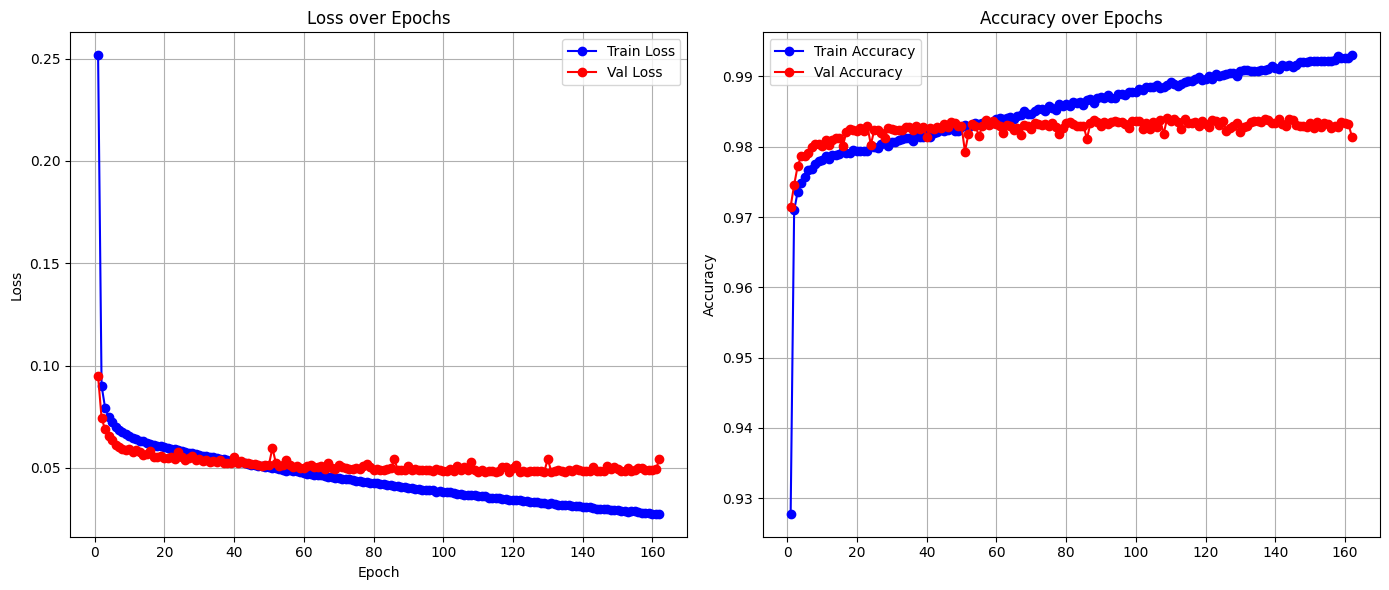

Full model built...
Total execution time: 306.09 seconds


(0.05410294777616367, 0.9814141978759083)

In [22]:
#@title No augmentation and Hyssopifolia is not in the validation set

remove_species=['lythrum_hyssopifolia']

model_name_BC2 = "no_hys_remove_from_val"
embeddings_save_path_BC2 = '/content/drive/MyDrive/Thesis/bioclip2_groups_embeddings_v0.pt'
create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=False, augmentation_factor=2, virgatum=False, bioclip_version=2,
                         output_dir="invasive_species", model_name=model_name_BC2, verbose=False, save_model=True, epochs=1000,
                         embeddings_save_path=embeddings_save_path_BC2, debug_subset_size=None, do_early_stopping=True,
                         remove_species=remove_species, keep_hys_in_val=False)

Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
✅ Embeddings already exist, loading from file...


Extracting embeddings: 100%|██████████| 68/68 [00:54<00:00,  1.24it/s]


Augmenting train dataset...
🔢 Class distribution in train set: Counter({1: 36980, 0: 29565})
⚖️ Class weights: tensor([0.0971, 0.0951])

🔁 Epoch 1/50


Evaluating: 100%|██████████| 224/224 [00:00<00:00, 1053.09it/s]



🔁 Epoch 2/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 224/224 [00:00<00:00, 1051.05it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 224/224 [00:00<00:00, 1034.50it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


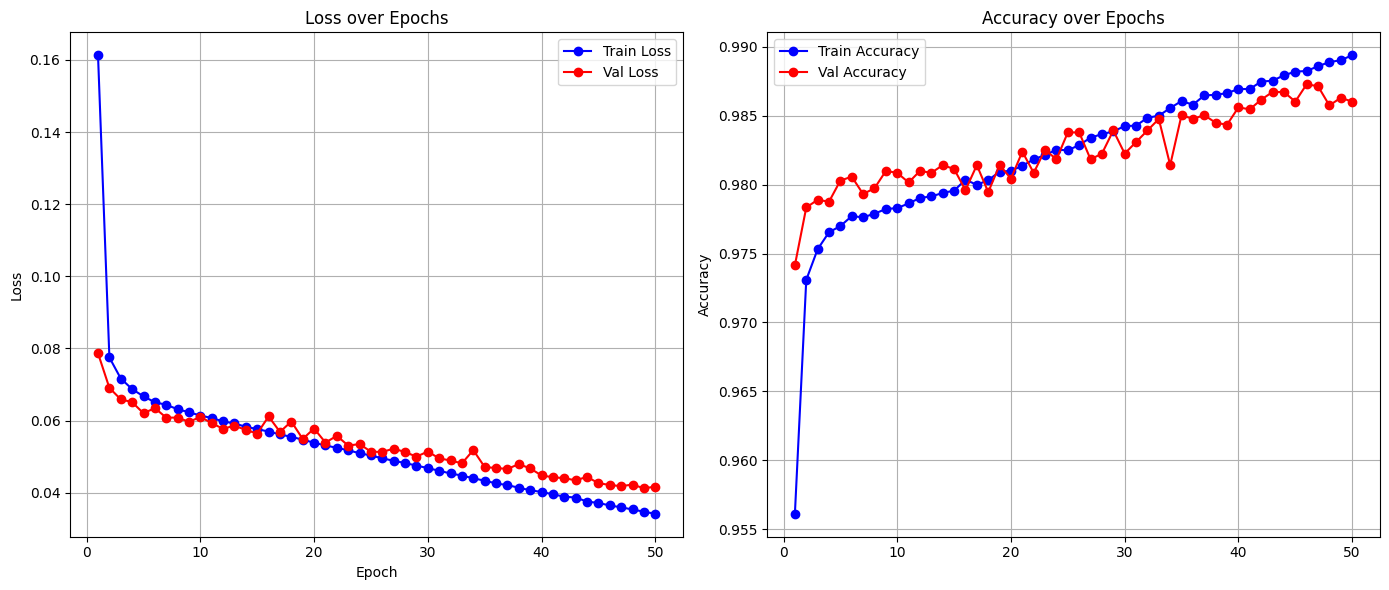

Full model built...
Total execution time: 1420.63 seconds


(0.04168449287413936, 0.9860257126886529)

In [ ]:
#@title x2 Augmentation (+ virgatum x2)

remove_species=['lythrum_hyssopifolia']

model_name_BC2 = "no_hys_remove_from_val_virgatum_x2_augmentation"
embeddings_save_path_BC2 = '/content/drive/MyDrive/Thesis/bioclip2_groups_embeddings_v0.pt'
create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=True, augmentation_factor=2, virgatum=True, bioclip_version=2,
                         output_dir="invasive_species", model_name=model_name_BC2, verbose=False, save_model=False, epochs=50,
                         embeddings_save_path=embeddings_save_path_BC2, debug_subset_size=None, do_early_stopping=True,
                         remove_species=remove_species, keep_hys_in_val=False)